# Importing the necessary libraries


In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Data Preprocessing

In [74]:
# Load the dataset
import pandas as pd

column_names = [
    "id",
    "diagnosis",
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave_points_mean",
    "symmetry_mean",
    "fractal_dimension_mean",
    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave_points_se",
    "symmetry_se",
    "fractal_dimension_se",
    "radius_worst",
    "texture_worst",
    "perimeter_worst",
    "area_worst",
    "smoothness_worst",
    "compactness_worst",
    "concavity_worst",
    "concave_points_worst",
    "symmetry_worst",
    "fractal_dimension_worst"
]

# Import the dataset
df = pd.read_csv("wdbc.csv", header=None, names=column_names)


In [75]:
# Display first few records
print("=" * 60)
print("First 5 Rows of the Dataset")
print("=" * 60)
print(df.head())

# Dataset shape
print("\nDataset Shape:", df.shape)

# Column names
print("\nColumn Names:")
print(df.columns)

# Dataset information
print("\nDataset Information")
print(df.info())

# Statistical summary
print("\nStatistical Summary")
print(df.describe())

# Check missing values
print("\nMissing Values")
print(df.isnull().sum())

First 5 Rows of the Dataset
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_wors

In [76]:
df.replace('?', np.nan, inplace=True)
df.isnull().sum()
# Removing unnecsessary columns
# Drop the ID column as it is only a unique identifier
df.drop(columns=["id"], inplace=True)
df.columns


Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave_points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [77]:
print("=" * 60)
print("Diagnosis Distribution")
print("=" * 60)
print(df["diagnosis"].value_counts())

Diagnosis Distribution
diagnosis
B    357
M    212
Name: count, dtype: int64


# EDA (Exploratory Data Analysis)

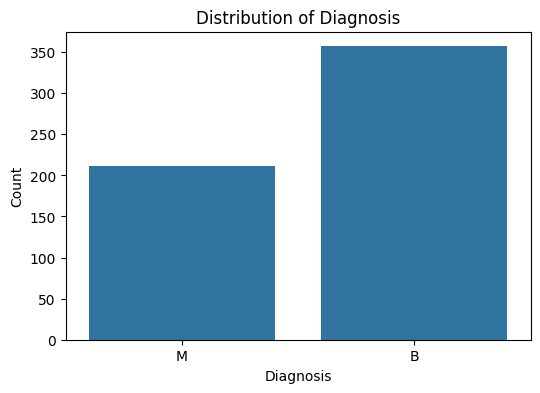

In [78]:
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x="diagnosis", data=df)

plt.title("Distribution of Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Count")

plt.show()

## Observation:
--> The dataset contains both benign and malignant tumors.  
-->The classes are reasonably balanced, making it suitable for classification

## Correlation

In [79]:
print("=" * 60)
print("Correlation Analysis")
print("=" * 60)

print("""
Correlation analysis helps identify relationships between
numerical features. Highly correlated features may contain
similar information, which can introduce redundancy.
This analysis also helps justify the use of PCA later in
the project.
""")

Correlation Analysis

Correlation analysis helps identify relationships between
numerical features. Highly correlated features may contain
similar information, which can introduce redundancy.
This analysis also helps justify the use of PCA later in
the project.



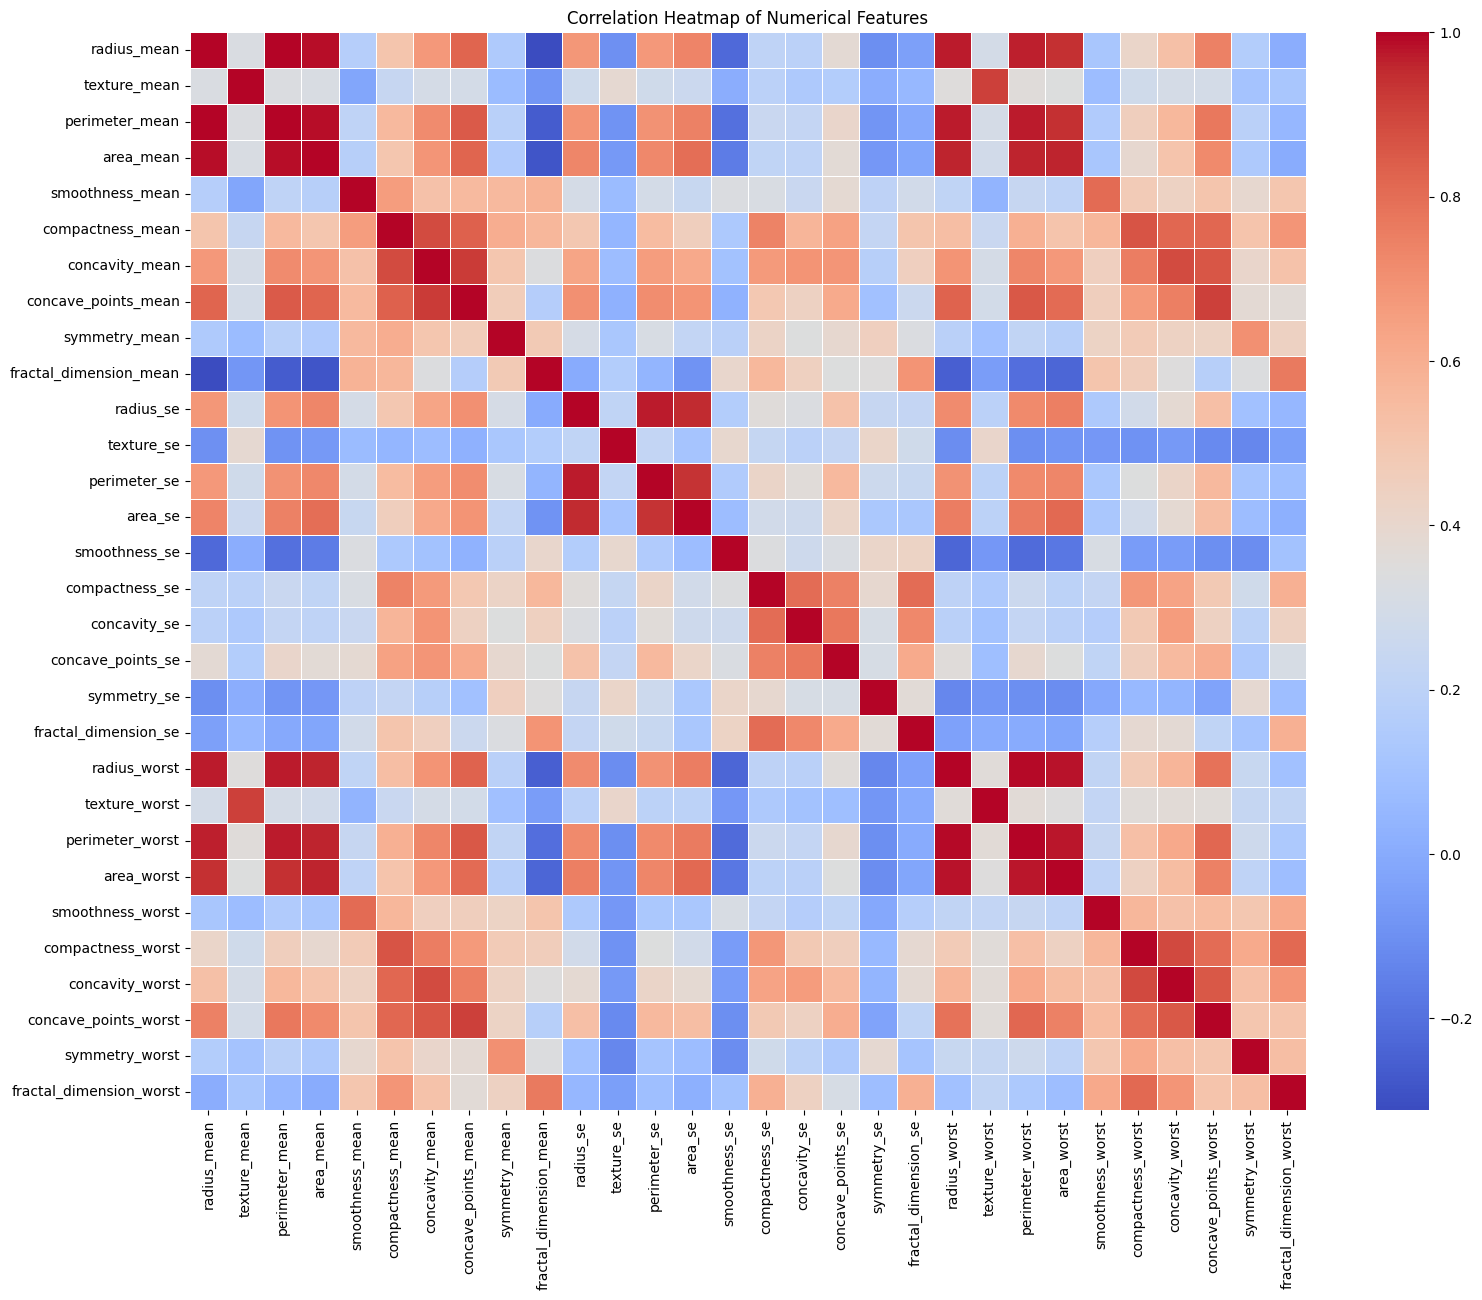

In [80]:
correlation_matrix = df.drop(columns=["diagnosis"]).corr()
plt.figure(figsize=(18,14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

### Observation
-->  Several features exhibit strong positive correlations.  
--> Highly correlated variables may contain overlapping information, which will increase redundancy and will lead directly to model complexity  

## Univariate Analysis


In [81]:
selected_features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "concavity_mean"
]

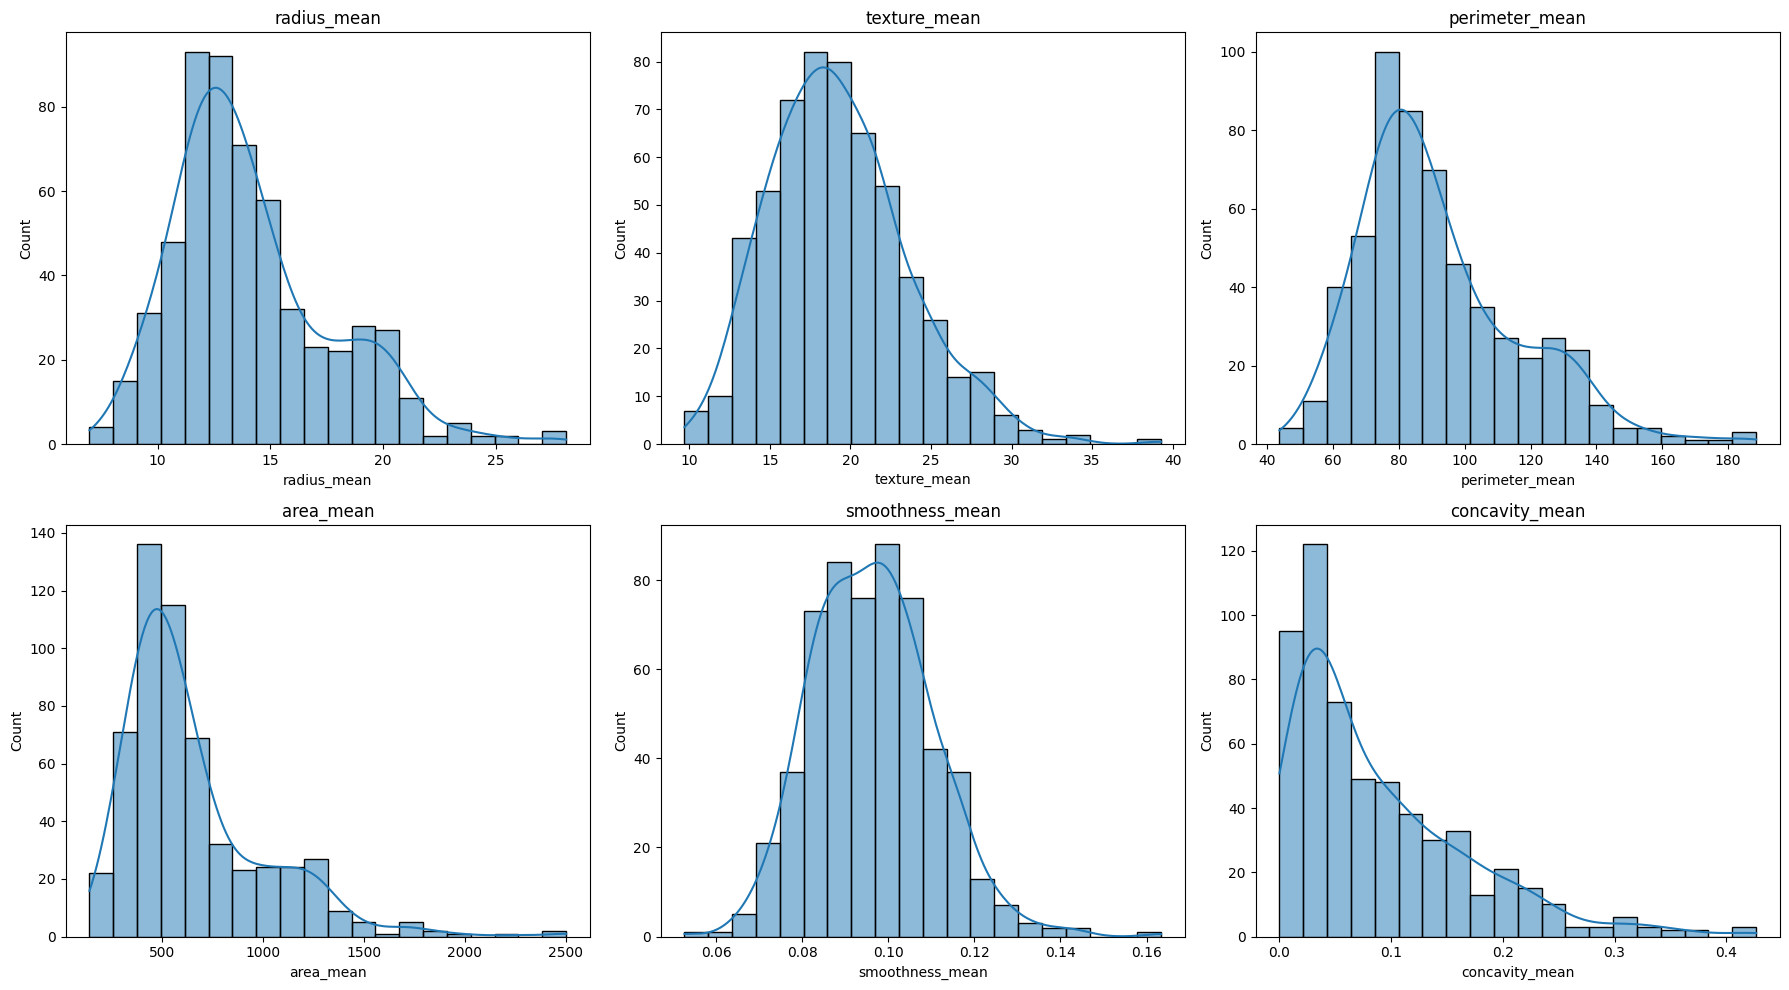

In [82]:
plt.figure(figsize=(18,10))

for i, feature in enumerate(selected_features, 1):

    plt.subplot(2,3,i)

    sns.histplot(
        data=df,
        x=feature,
        bins=20,
        kde=True
    )

    plt.title(feature)

plt.tight_layout()

plt.show()

## Outlier Detection using Boxplots

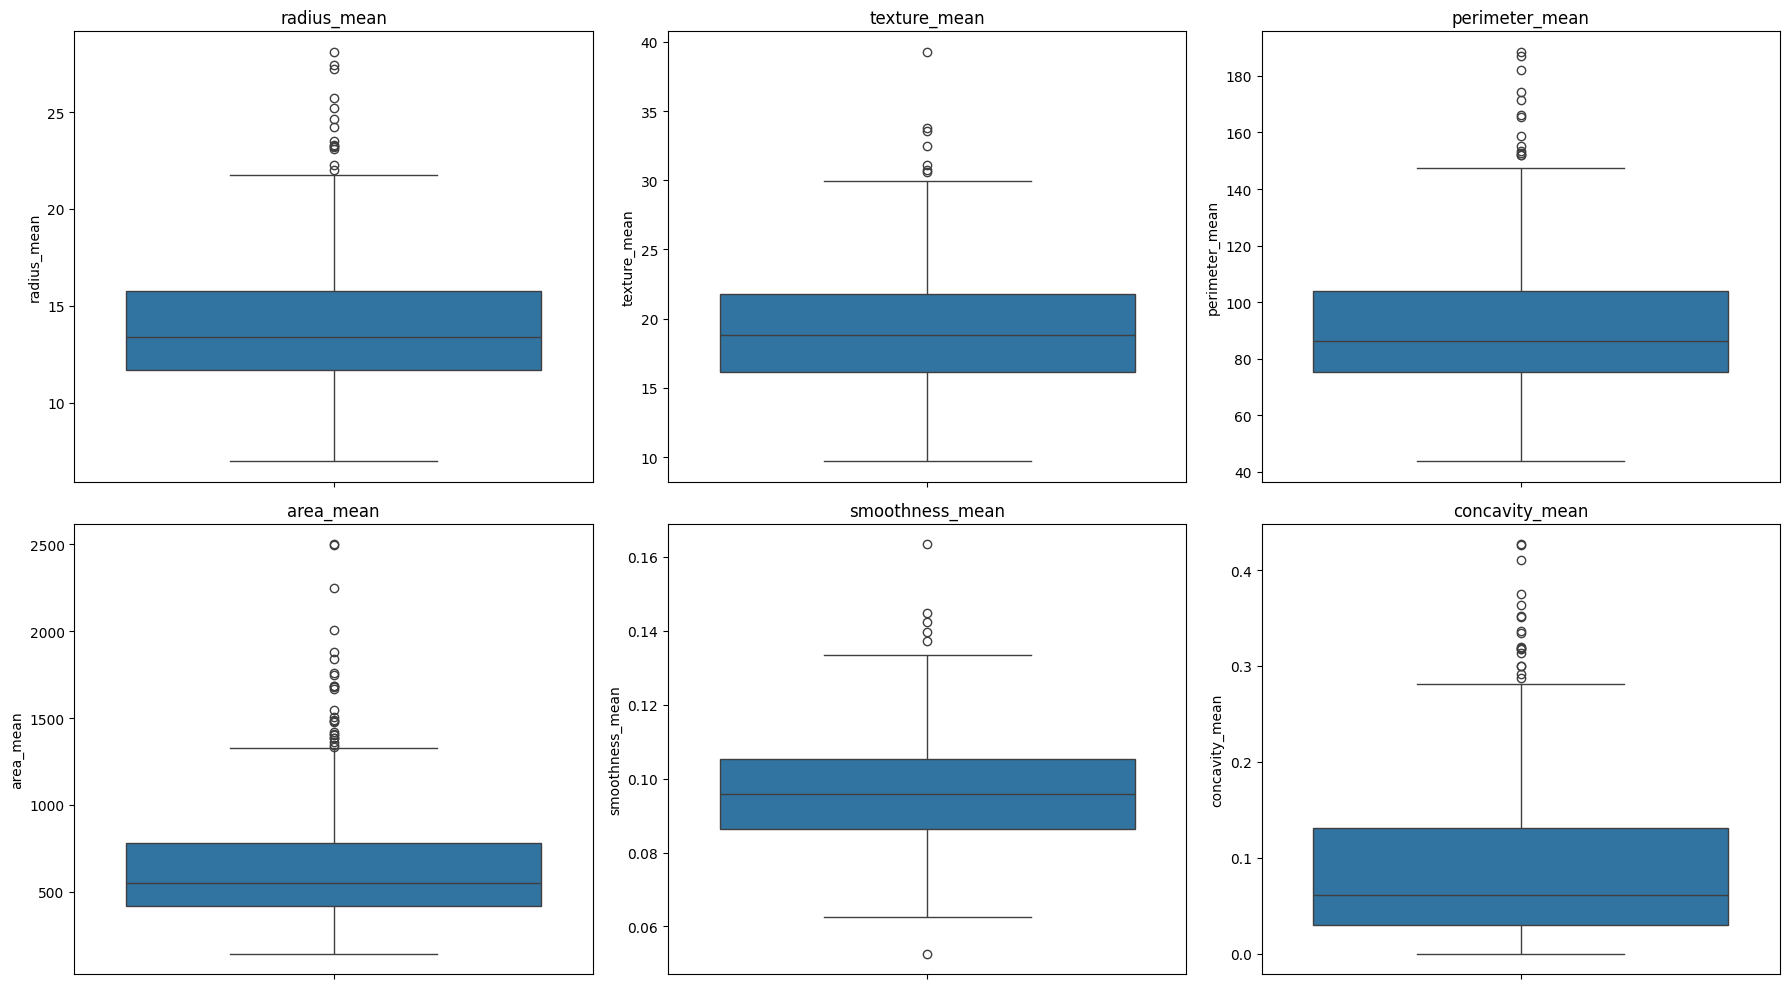

In [83]:
plt.figure(figsize=(18,10))

for i, feature in enumerate(selected_features, 1):

    plt.subplot(2,3,i)

    sns.boxplot(y=df[feature])

    plt.title(feature)

plt.tight_layout()

plt.show()

### Observation

--> Several numerical features contain potential outliers, as indicated by the points beyond the whiskers of the boxplots.

--> Features such as `area_mean`, `perimeter_mean`, and `concavity_mean` exhibit a comparatively higher number of extreme observations.

--> These outliers are likely to represent genuine medical variations rather than data entry errors, making them valuable for the analysis.

--> Therefore, the detected outliers will be retained in the dataset instead of being removed to preserve important information for model training.

## Bivariate Analysis

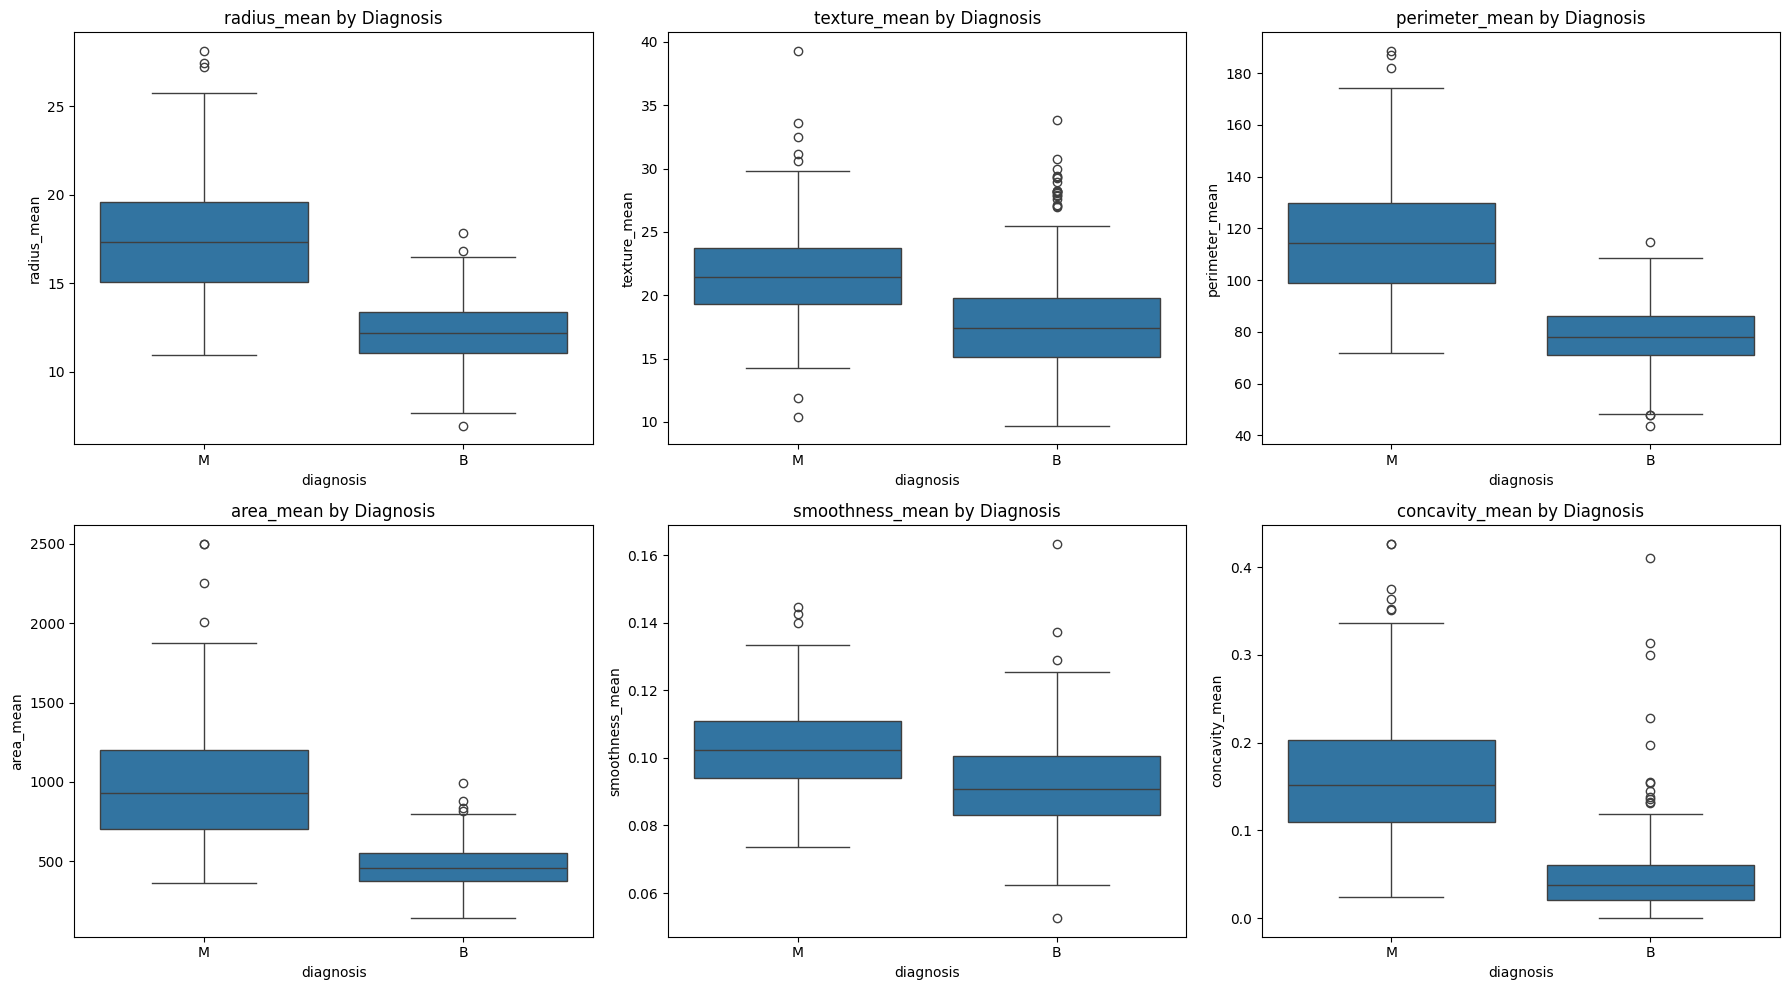

In [84]:
selected_features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "concavity_mean"
]

plt.figure(figsize=(18,10))

for i, feature in enumerate(selected_features, 1):

    plt.subplot(2,3,i)

    sns.boxplot(
        x="diagnosis",
        y=feature,
        data=df
    )

    plt.title(f"{feature} by Diagnosis")

plt.tight_layout()
plt.show()

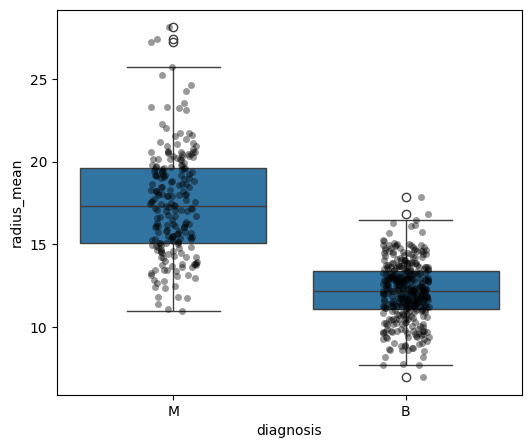

In [85]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x="diagnosis",
    y="radius_mean",
    data=df
)

sns.stripplot(
    x="diagnosis",
    y="radius_mean",
    data=df,
    color="black",
    alpha=0.4
)

plt.show()

# Train Test Split

In [86]:
df["diagnosis"] = df["diagnosis"].map({
    "M": 1,
    "B": 0
})

df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [87]:
X = df.drop("diagnosis", axis=1)

y = df["diagnosis"]

print("Feature Variables Shape:", X.shape)
print("Target Variable Shape:", y.shape)

Feature Variables Shape: (569, 30)
Target Variable Shape: (569,)


In [88]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Feature Scaling

In [89]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

###Observation:
--> This is done to deal with outliers and unitlise them instead of removing them.   
--> fit_transform is done once in train data to avoid Data Leakage.

#PCA

In [90]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)

X_test_pca = pca.transform(X_test_scaled)

print("Original Features :", X_train.shape[1])
print("Reduced Features  :", X_train_pca.shape[1])

Original Features : 30
Reduced Features  : 10


In [91]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Explained Variance:", pca.explained_variance_ratio_.sum())

Explained Variance Ratio: [0.44593522 0.18545255 0.09584641 0.06593768 0.05622286 0.03988488
 0.02214493 0.01614006 0.01284789 0.01165661]
Total Explained Variance: 0.9520691014391004


### Observation:
--> PCA is mainly done for dimentionality reduction, if the numbe of features are too high that could lead to an even inferior model.   
--> Also, PCA is perfect for distance based models so a perfect addition

#Training the Model

##KNN (K-Nearest Neighbors)

In [92]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train_pca, y_train)

KNeighborsClassifier()

In [93]:
y_pred_knn = knn.predict(X_test_pca)

In [94]:
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

print("\nClassification Report")
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.956140350877193

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### Confusion Matrix

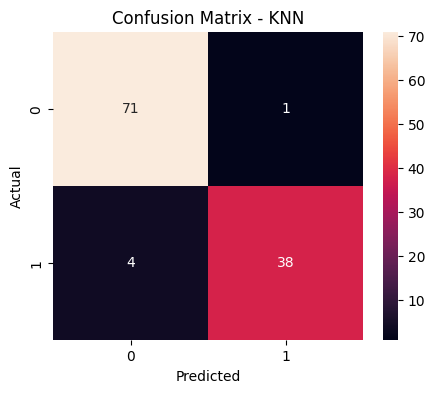

In [95]:
cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True

)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN")

plt.show()

## SVM (Support Vector Machine)

In [96]:
svm = SVC(random_state=42)

svm.fit(X_train_pca, y_train)

SVC(random_state=42)

In [97]:
y_pred_svm = svm.predict(X_test_pca)

In [98]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nClassification Report")
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.9649122807017544

Classification Report
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



### Confusion Matrix

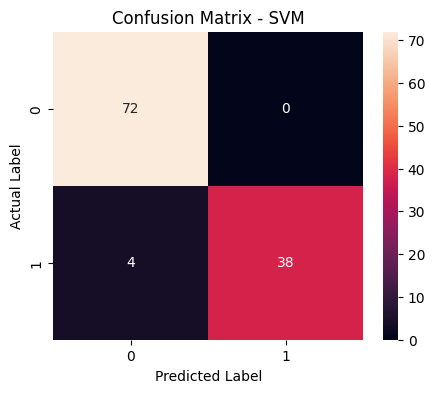

In [99]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,

)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - SVM")

plt.show()

# Hyperparameter Tuning

##Hyperparameter Tuning for KNN

In [100]:
from sklearn.model_selection import GridSearchCV

param_grid_knn = {
    "n_neighbors": list(range(1,21)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid_knn,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_knn.fit(X_train_pca, y_train)

print("Best Parameters:", grid_knn.best_params_)
print("Best Cross Validation Accuracy:", grid_knn.best_score_)

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
Best Cross Validation Accuracy: 0.9670329670329672


In [101]:
print(grid_knn.best_estimator_)

KNeighborsClassifier(metric='euclidean')


In [102]:
best_knn = grid_knn.best_estimator_

best_knn.fit(X_train_pca, y_train)

KNeighborsClassifier(metric='euclidean')

In [103]:
y_pred_best_knn = best_knn.predict(X_test_pca)

In [104]:
print("Accuracy:", accuracy_score(y_test, y_pred_best_knn))

print(classification_report(y_test, y_pred_best_knn))

Accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### Confusion Matrix

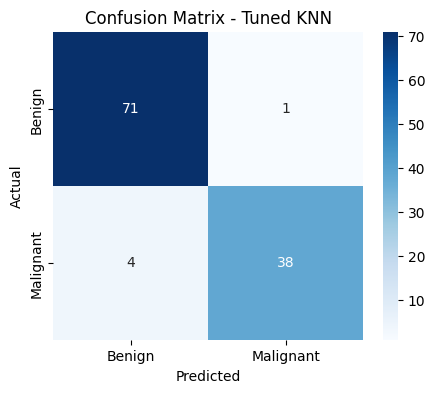

In [105]:
cm = confusion_matrix(y_test, y_pred_best_knn)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign","Malignant"],
    yticklabels=["Benign","Malignant"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned KNN")

plt.show()

## Hyperparameter Tuning for SVM

In [106]:
param_grid_svm = {
    "C":[0.1,1,10,100],
    "kernel":["linear","rbf"],
    "gamma":["scale","auto"]
}

grid_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid_svm,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_svm.fit(X_train_pca,y_train)

print("Best Parameters:",grid_svm.best_params_)
print("Best Cross Validation Accuracy:",grid_svm.best_score_)

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best Cross Validation Accuracy: 0.9758241758241759


In [107]:
best_svm = grid_svm.best_estimator_

best_svm.fit(X_train_pca,y_train)

SVC(C=1, kernel='linear', random_state=42)

In [108]:
y_pred_best_svm = best_svm.predict(X_test_pca)

In [109]:
print("Accuracy:",accuracy_score(y_test,y_pred_best_svm))

print(classification_report(y_test,y_pred_best_svm))

Accuracy: 0.9649122807017544
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



### Confusion Matrix

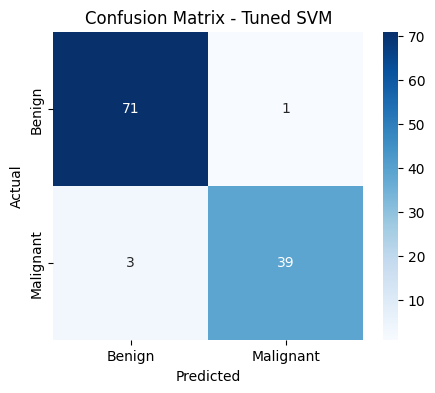

In [110]:
cm = confusion_matrix(y_test,y_pred_best_svm)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign","Malignant"],
    yticklabels=["Benign","Malignant"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned SVM")

plt.show()

### Comparison

In [111]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline KNN",
        "Tuned KNN",
        "Baseline SVM",
        "Tuned SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_best_knn),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_best_svm)
    ]
})

comparison

,Model,Accuracy
0,Baseline KNN,0.956140
1,Tuned KNN,0.956140
2,Baseline SVM,0.964912
3,Tuned SVM,0.964912


### ROC Curve

In [112]:
from sklearn.metrics import roc_curve, auc

knn_prob = best_knn.predict_proba(X_test_pca)[:,1]

fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_prob)

auc_knn = auc(fpr_knn, tpr_knn)

In [113]:
best_svm = SVC(**grid_svm.best_params_, probability=True, random_state=42)

best_svm.fit(X_train_pca, y_train)

svm_prob = best_svm.predict_proba(X_test_pca)[:,1]

fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_prob)

auc_svm = auc(fpr_svm, tpr_svm)

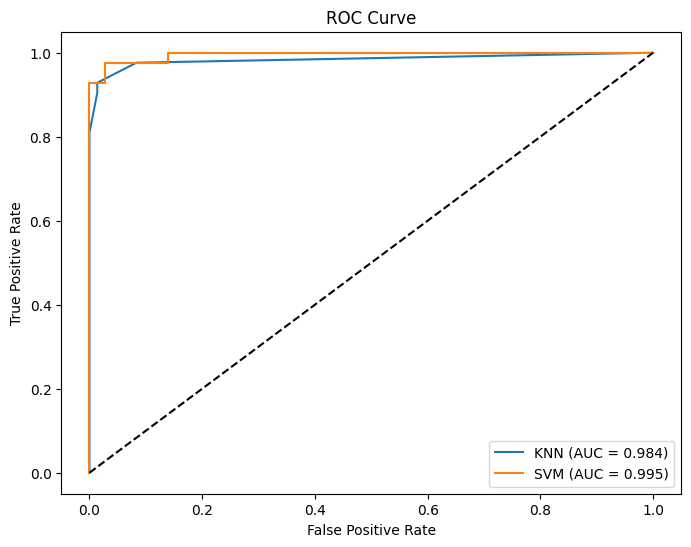

In [114]:
plt.figure(figsize=(8,6))

plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {auc_knn:.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

# CONCLUSION


--> This project focused on building and evaluating machine learning models to classify breast cancer tumors as either benign or malignant using the Wisconsin Diagnostic Breast Cancer dataset.

--> A detailed Exploratory Data Analysis (EDA) was carried out to better understand the dataset. This included analyzing feature distributions, identifying outliers, examining the class distribution, and exploring relationships between features through various visualizations.

--> The correlation analysis revealed that several features were highly correlated, indicating the presence of redundant information. To address this, Principal Component Analysis (PCA) was applied to reduce the dimensionality of the dataset while preserving most of the important information.

--> Before training the models, the data was preprocessed by encoding the target variable, splitting the dataset into training and testing sets, and standardizing the numerical features to ensure consistent model performance.

--> Two machine learning algorithms, K-Nearest Neighbors (KNN) and Support Vector Machine (SVM), were first trained using their default hyperparameters to establish baseline performance.

--> Hyperparameter tuning was then performed using GridSearchCV with 5-fold cross-validation to determine whether better parameter combinations could further improve the models' performance.

--> The tuned models achieved performance similar to their baseline counterparts, suggesting that the default hyperparameter settings were already well-suited for this dataset.

--> Model performance was assessed using multiple evaluation metrics, including Accuracy, Precision, Recall, F1-score, Confusion Matrix, and ROC-AUC, providing a comprehensive understanding of each model's strengths and overall predictive capability.

--> The ROC curve analysis demonstrated excellent classification performance for both models. KNN achieved an AUC score of `0.984`, while SVM achieved an AUC score of `0.995`, indicating that both models were highly effective at distinguishing between benign and malignant tumors.

--> Among the evaluated models, the Support Vector Machine (SVM) consistently delivered the strongest overall performance, achieving the highest accuracy and ROC-AUC score. Based on these results, SVM was selected as the final model for this classification task.

--> Overall, this project highlights the importance of thorough data exploration, careful preprocessing, and systematic model evaluation. The results demonstrate that machine learning can accurately classify breast cancer cases and has the potential to support faster and more reliable clinical decision-making.

# Pickling the Files

In [115]:
import os
import pickle
import shutil
from google.colab import files

# Create artifacts folder
os.makedirs("artifacts", exist_ok=True)

# Save the trained objects
with open("artifacts/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("artifacts/pca.pkl", "wb") as f:
    pickle.dump(pca, f)

with open("artifacts/svm_model.pkl", "wb") as f:
    pickle.dump(best_svm, f)

# Create a ZIP file of the artifacts folder
shutil.make_archive("artifacts", "zip", "artifacts")

print("✅ Files saved successfully!")
print("Contents of artifacts folder:", os.listdir("artifacts"))

# Download the ZIP file
files.download("artifacts.zip")

✅ Files saved successfully!
Contents of artifacts folder: ['scaler.pkl', 'svm_model.pkl', 'pca.pkl']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>